# 🐶🐱 Cats vs Dogs Classification – Complete Teaching Demo
## HOG vs CNN Features + SVM + Visualizations

This notebook demonstrates:
- HOG feature extraction + visualization
- CNN (ResNet18) feature extraction
- Grad-CAM visualization
- Saving features to CSV
- SVM training
- Confusion matrix
- ROC curve
- Performance comparison

In [32]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage.feature import hog
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_curve, auc
import seaborn as sns
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
%matplotlib inline

## Dataset Structure
```
dataset/
   cats/
   dogs/
```

In [36]:
data_dir = "/kaggle/input/datasets/bhavikjikadara/dog-and-cat-classification-dataset/PetImages"

## 1️⃣ HOG Feature Extraction + Visualization

Corrupt JPEG data: 226 extraneous bytes before marker 0xd9
Corrupt JPEG data: 65 extraneous bytes before marker 0xd9
Corrupt JPEG data: 254 extraneous bytes before marker 0xd9
Corrupt JPEG data: 1403 extraneous bytes before marker 0xd9
Corrupt JPEG data: 162 extraneous bytes before marker 0xd9
Corrupt JPEG data: 2230 extraneous bytes before marker 0xd9
Corrupt JPEG data: 399 extraneous bytes before marker 0xd9
Corrupt JPEG data: 239 extraneous bytes before marker 0xd9
Corrupt JPEG data: 99 extraneous bytes before marker 0xd9
Corrupt JPEG data: 214 extraneous bytes before marker 0xd9
Corrupt JPEG data: 128 extraneous bytes before marker 0xd9
Corrupt JPEG data: 1153 extraneous bytes before marker 0xd9


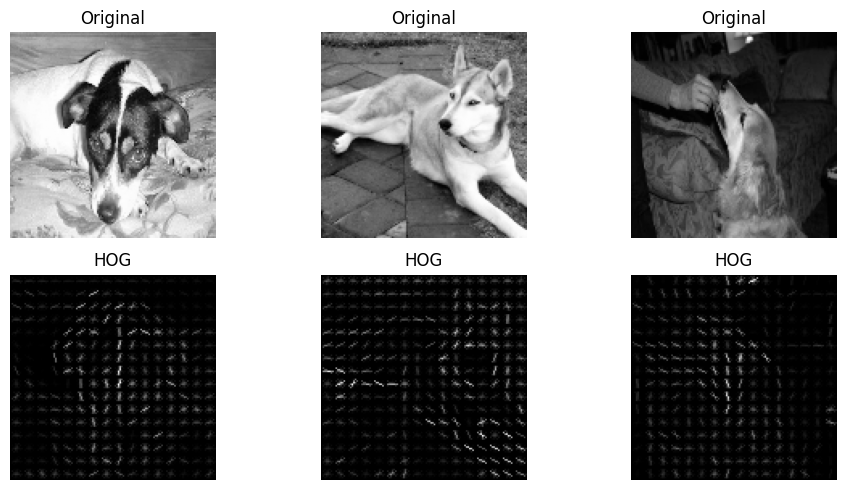

In [67]:
hog_features = []
hog_labels = []
plt.figure(figsize=(10,5))
display_count = 0

for label in os.listdir(data_dir):
    for file in os.listdir(os.path.join(data_dir, label)):
        img_path = os.path.join(data_dir, label, file)
       
        try:
           img = cv2.imread(img_path)

           if img is None:
              continue

           img = cv2.resize(img, (128,128))
           gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        except:
            continue

        features, hog_img = hog(gray, orientations=9,
                                pixels_per_cell=(8,8),
                                cells_per_block=(2,2),
                                visualize=True)
        hog_features.append(features)
        hog_labels.append(label)

        if display_count < 3:
            plt.subplot(2,3,display_count+1)
            plt.imshow(gray, cmap='gray')
            plt.title('Original')
            plt.axis('off')
            plt.subplot(2,3,display_count+4)
            plt.imshow(hog_img, cmap='gray')
            plt.title('HOG')
            plt.axis('off')
            display_count += 1

plt.tight_layout()
plt.show()

In [69]:
import cv2
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

img = cv2.imread("your_image.jpg")

[ WARN:0@5384.256] global loadsave.cpp:275 findDecoder imread_('your_image.jpg'): can't open/read file: check file path/integrity


In [70]:
hog_df = pd.DataFrame(hog_features)
hog_df['label'] = hog_labels
hog_df.to_csv('hog_features.csv', index=False)
hog_df.head()

,0,1,2,3,4,5,6,7,8,9,...,8091,8092,8093,8094,8095,8096,8097,8098,8099,label
0,0.032172,0.003128,0.005043,0.197402,0.297989,0.297989,0.198135,0.027982,0.004423,0.067141,...,0.245794,0.245794,0.245794,0.122279,0.222092,0.092706,0.032238,0.150090,0.177779,Dog
1,0.258973,0.086154,0.175565,0.258973,0.258973,0.200007,0.102378,0.084238,0.138475,0.170356,...,0.050591,0.001142,0.000000,0.000000,0.230439,0.200192,0.384770,0.008488,0.018609,Dog
2,0.085412,0.057742,0.038826,0.035720,0.027454,0.000000,0.025884,0.023248,0.050339,0.248583,...,0.293138,0.149463,0.009146,0.000000,0.045270,0.055362,0.023317,0.139327,0.092595,Dog
3,0.384140,0.000000,0.017613,0.008558,0.056215,0.004641,0.011742,0.015020,0.384140,0.263616,...,0.115035,0.118406,0.029423,0.151963,0.161858,0.227872,0.197084,0.116137,0.157705,Dog
4,0.121608,0.063503,0.084918,0.030774,0.050334,0.006109,0.020625,0.008639,0.028177,0.345924,...,0.227361,0.144347,0.097830,0.156758,0.227361,0.227361,0.141485,0.095892,0.109964,Dog


## Train SVM on HOG Features

In [ ]:
X = hog_df.drop('label', axis=1).values
y = hog_df['label'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

svm_hog = SVC(kernel='rbf', probability=True)
svm_hog.fit(X_train, y_train)

y_pred = svm_hog.predict(X_test)
print('HOG Accuracy:', accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

In [ ]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix - HOG')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
y_prob = svm_hog.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve((y_test=='dogs').astype(int), y_prob)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr)
plt.title(f'ROC Curve (AUC = {roc_auc:.2f})')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.show()

## 2️⃣ CNN Feature Extraction (ResNet18)

In [ ]:
model = models.resnet18(pretrained=True)
model = torch.nn.Sequential(*list(model.children())[:-1])
model.eval()

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

dataset = ImageFolder(data_dir, transform=transform)
loader = DataLoader(dataset, batch_size=32, shuffle=False)

cnn_features = []
cnn_labels = []

with torch.no_grad():
    for imgs, lbls in loader:
        output = model(imgs)
        output = output.view(output.size(0), -1)
        cnn_features.append(output.numpy())
        cnn_labels.append(lbls.numpy())

X_cnn = np.vstack(cnn_features)
y_cnn = np.hstack(cnn_labels)

In [ ]:
X_train_cnn, X_test_cnn, y_train_cnn, y_test_cnn = train_test_split(
    X_cnn, y_cnn, test_size=0.2, random_state=42)

svm_cnn = SVC(kernel='rbf')
svm_cnn.fit(X_train_cnn, y_train_cnn)

y_pred_cnn = svm_cnn.predict(X_test_cnn)
print('CNN Feature Accuracy:', accuracy_score(y_test_cnn, y_pred_cnn))

## 3️⃣ Performance Comparison

In [ ]:
print('HOG Accuracy:', accuracy_score(y_test, y_pred))
print('CNN Accuracy:', accuracy_score(y_test_cnn, y_pred_cnn))